# CIFAR 10 Dataset

The CIFAR-10 dataset is an image database for classification tasks. It consists of 60,000 color images, each with a resolution of 32×32 pixels, divided into 10 different classes. The classes are: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

The dataset is split into: 50,000 training images, 10,000 testing images

Each class contains 6,000 images, making the dataset balanced across categories. CIFAR-10 was created by researchers at the Canadian Institute For Advanced Research and is commonly used to evaluate image classification algorithms, especially convolutional neural networks (CNNs).

Because the images are small and relatively simple, CIFAR-10 is often used as an introductory dataset for deep learning experiments and benchmarking model performance.

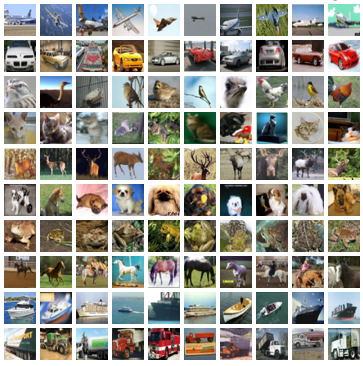

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train.shape: (50000, 32, 32, 3)
y_train.shape (50000,)


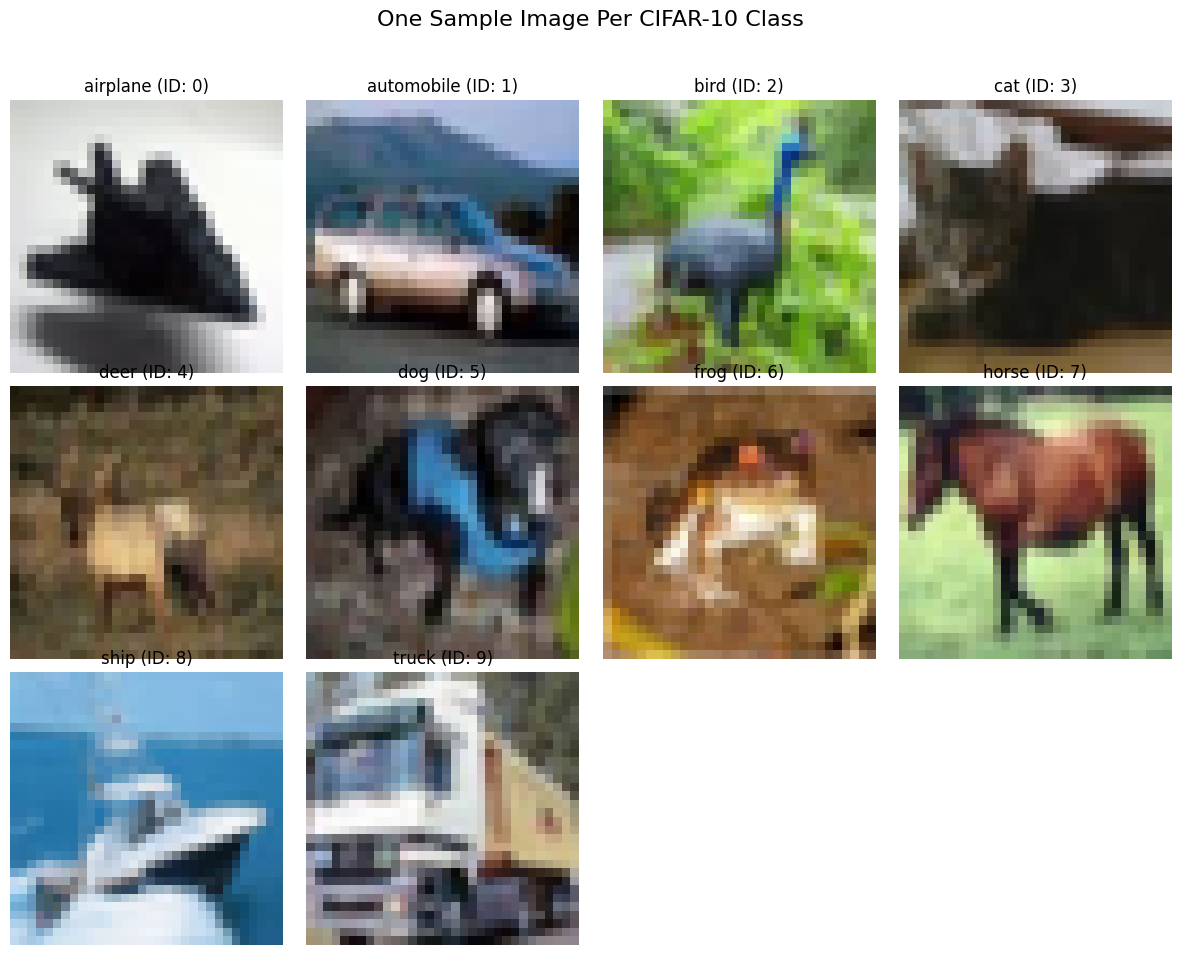


Training data points per class:
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000

Testing data points per class:
airplane: 1000
automobile: 1000
bird: 1000
cat: 1000
deer: 1000
dog: 1000
frog: 1000
horse: 1000
ship: 1000
truck: 1000
Number of classes: 10


In [1]:
#CIFAR10 DATASET

import tensorflow as tf
import numpy as no
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
import pandas as pd

cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print("x_train.shape:", x_train.shape)
print("y_train.shape", y_train.shape)

# Define CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

#Explore dataset - Images
images_per_class = {}

for i in range(len(x_train)):
    label_id = y_train[i] # Corrected from y_train[i][0]
    if label_id not in images_per_class:
        images_per_class[label_id] = x_train[i]
    if len(images_per_class) == len(class_names):
        break

sorted_images = sorted(images_per_class.items())

plt.figure(figsize=(12, 10))
plt.suptitle("One Sample Image Per CIFAR-10 Class", fontsize=16)

for i, (label_id, image_data) in enumerate(sorted_images):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image_data)
    plt.title(f"{class_names[label_id]} (ID: {label_id})")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Explore dataset - Numbers
train_counts = pd.Series(y_train.flatten()).value_counts().sort_index()
print("\nTraining data points per class:")
for i, count in enumerate(train_counts):
    print(f"{class_names[i]}: {count}")

test_counts = pd.Series(y_test.flatten()).value_counts().sort_index()
print("\nTesting data points per class:")
for i, count in enumerate(test_counts):
    print(f"{class_names[i]}: {count}")

#Prepare to deploy the model
K = len(set(y_train))
print("Number of classes:", K)

#Data augmentation
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
  ]
)

i = Input(shape = x_train[0].shape)
x = data_augmentation(i)

In [2]:
#CIFAR (2/N) - Building the model

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)

# x = GlobalMaxPooling2D()(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [3]:
#CIFAR (3/N) - Compile
# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Fit with data augmentation
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.4611 - loss: 1.5412 - val_accuracy: 0.5399 - val_loss: 1.3719
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.5877 - loss: 1.1745 - val_accuracy: 0.6064 - val_loss: 1.1658
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6434 - loss: 1.0236 - val_accuracy: 0.5451 - val_loss: 1.3660
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.6807 - loss: 0.9260 - val_accuracy: 0.7076 - val_loss: 0.8600
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7057 - loss: 0.8506 - val_accuracy: 0.7156 - val_loss: 0.8889
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.7275 - loss: 0.7945 - val_accuracy: 0.7181 - val_loss: 0.8885
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7424 - loss: 0.7515 - val_accuracy: 0.7469 - val_loss: 0.7549
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7556 -

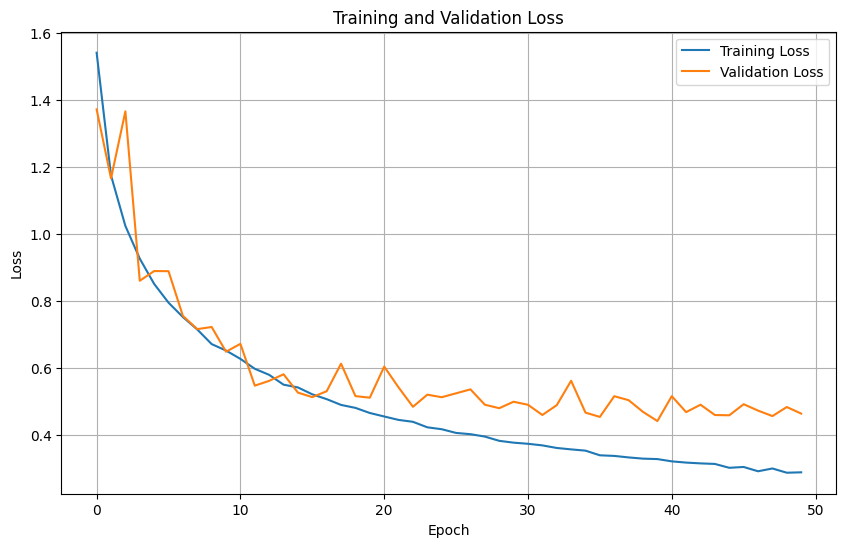

In [4]:
#CIFAR (4/N) - Evaluate the model
import matplotlib.pyplot as plt

# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

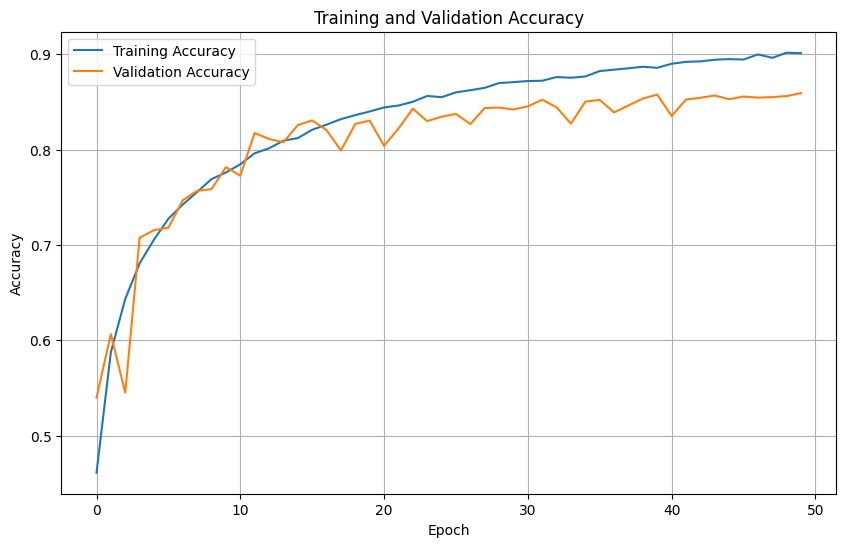

In [5]:
#CIFAR (5/N) - Evaluate the model
plt.figure(figsize=(10, 6))
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


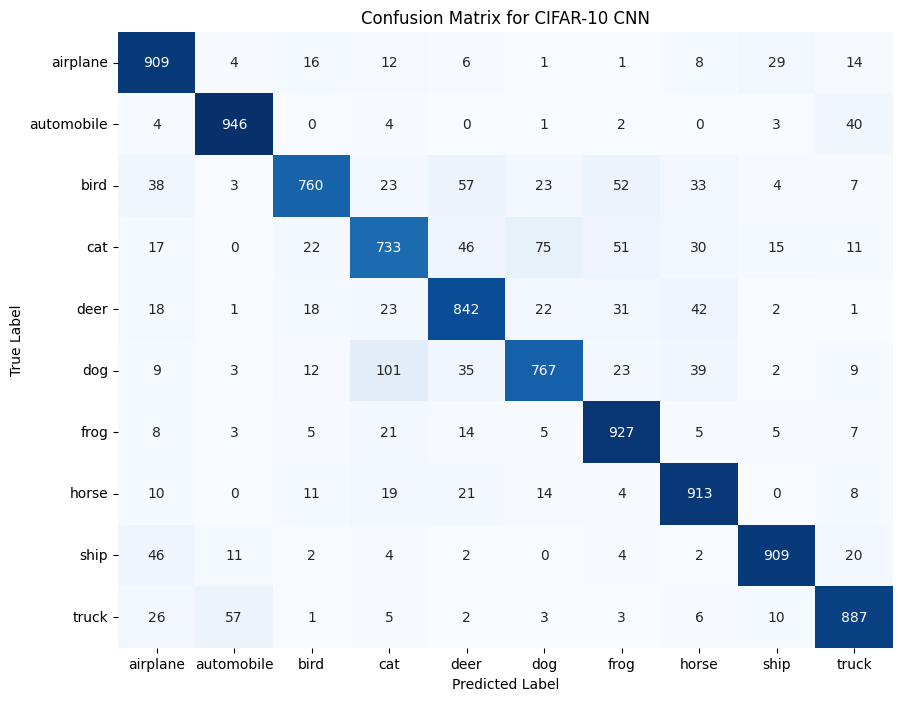

In [6]:
#CIFAR (6/N) - Create the confusion matrix

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred_probabilities = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CIFAR-10 CNN')
plt.show()

Top misclassified archetypes:
  Actual 'dog' predicted as 'cat' (101 times)
  Actual 'cat' predicted as 'dog' (75 times)
  Actual 'bird' predicted as 'deer' (57 times)
  Actual 'truck' predicted as 'automobile' (57 times)
  Actual 'bird' predicted as 'frog' (52 times)
  Actual 'cat' predicted as 'frog' (51 times)
  Actual 'cat' predicted as 'deer' (46 times)
  Actual 'ship' predicted as 'airplane' (46 times)
  Actual 'deer' predicted as 'horse' (42 times)
  Actual 'automobile' predicted as 'truck' (40 times)

Displaying 10 unique misclassified examples.


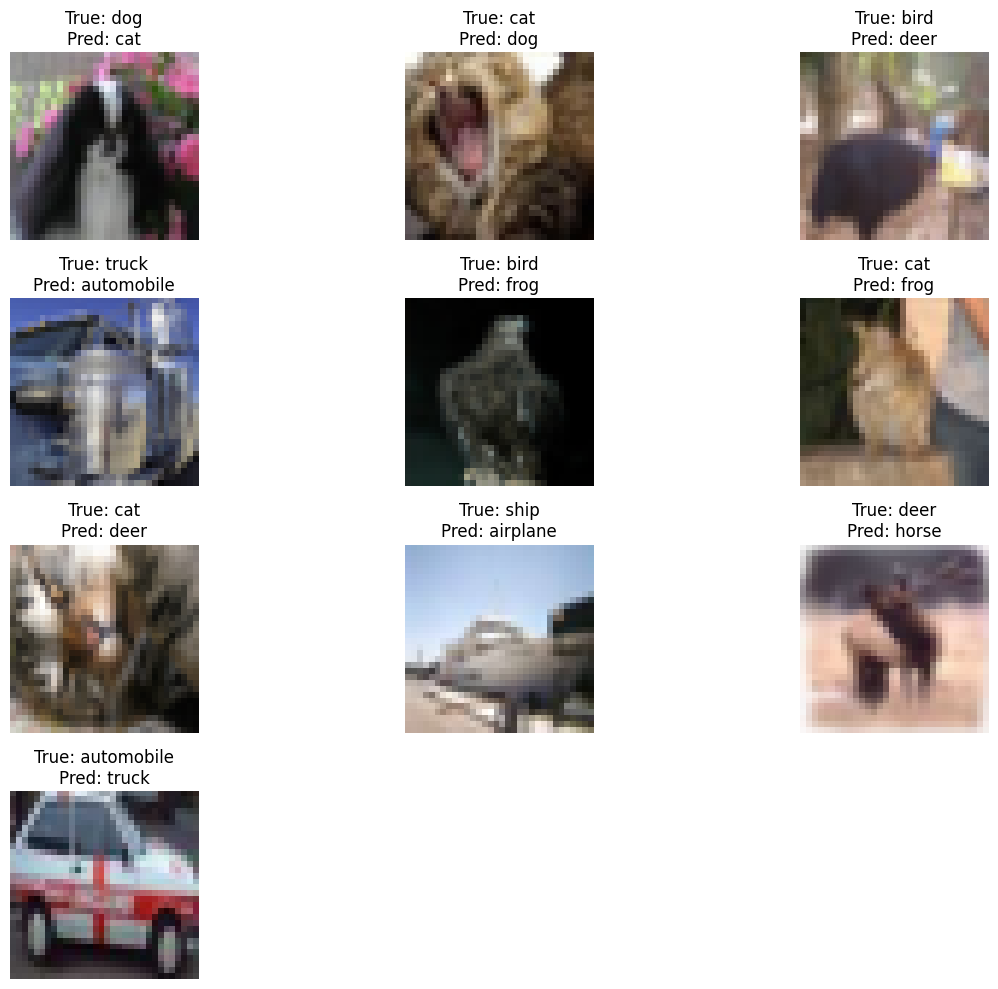

In [7]:
#CIFAR (7/N) - Mis-classified Examples

import matplotlib.pyplot as plt
import numpy as np

# Find multiple misclassified pairs based on the confusion matrix
misclassification_counts = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0: # Only consider actual misclassifications
            misclassification_counts.append((cm[i, j], i, j)) # Store (count, true_label, predicted_label)

# Sort by count in descending order
misclassification_counts.sort(key=lambda x: x[0], reverse=True)

# Get up to 10 unique misclassified archetypes
unique_misclassified_archetypes = []
seen_pairs = set()
for count, true_class_idx, pred_class_idx in misclassification_counts:
    if (true_class_idx, pred_class_idx) not in seen_pairs:
        unique_misclassified_archetypes.append((true_class_idx, pred_class_idx))
        seen_pairs.add((true_class_idx, pred_class_idx))
    if len(unique_misclassified_archetypes) >= 10:
        break

print("Top misclassified archetypes:")
for true_idx, pred_idx in unique_misclassified_archetypes:
    count = cm[true_idx, pred_idx]
    print(f"  Actual '{class_names[true_idx]}' predicted as '{class_names[pred_idx]}' ({count} times)")

# Collect one example for each unique misclassified archetype
examples_to_display = []
for true_class_idx, pred_class_idx in unique_misclassified_archetypes:
    # Find an index where this specific misclassification occurred
    for idx in range(len(y_test)):
        if y_test[idx] == true_class_idx and y_pred_classes[idx] == pred_class_idx:
            examples_to_display.append(idx)
            break # Found one example for this archetype, move to the next

print(f"\nDisplaying {len(examples_to_display)} unique misclassified examples.")

# Display these specific misclassified examples
plt.figure(figsize=(12, 10))
num_rows = (len(examples_to_display) + 2) // 3 # Calculate rows needed for 3 columns
for i, bad_index in enumerate(examples_to_display):
    plt.subplot(num_rows, 3, i + 1)
    plt.imshow(x_test[bad_index]) # CIFAR-10 images are already 3-channel (RGB)
    plt.title(f"True: {class_names[y_test[bad_index]]}\nPred: {class_names[y_pred_classes[bad_index]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()